# 1. Importación de Librerías


In [1]:
# Importación de librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


# 2. Generación del Dataset Sintético


In [2]:
print("🔧 Generando dataset sintético...")
print("=" * 60)

# Parámetros del dataset
n_muestras = 1000  # Total de muestras
n_caracteristicas = 5  # Número de características
porcentaje_anomalias = 0.05  # 5% de anomalías

# Generar datos normales (95%)
np.random.seed(42)
datos_normales, _ = make_blobs(
    n_samples=int(n_muestras * (1 - porcentaje_anomalias)),
    n_features=n_caracteristicas,
    centers=1,
    cluster_std=1.0,
    random_state=42
)

# Generar anomalías (5%) - más dispersas y alejadas
anomalias = np.random.uniform(
    low=-10,
    high=10,
    size=(int(n_muestras * porcentaje_anomalias), n_caracteristicas)
)

# Combinar datos normales y anomalías
X = np.vstack([datos_normales, anomalias])
y = np.array([0] * len(datos_normales) + [1] * len(anomalias))  # 0=normal, 1=anomalía

# Mezclar los datos
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

# Crear DataFrame para mejor visualización
columnas = [f'Caracteristica_{i+1}' for i in range(n_caracteristicas)]
df = pd.DataFrame(X, columns=columnas)
df['Es_Anomalia'] = y
df['Tipo'] = df['Es_Anomalia'].map({0: 'Normal', 1: 'Anomalía'})

print(f"📊 Dataset creado exitosamente")
print(f"   - Muestras totales: {len(df)}")
print(f"   - Características: {n_caracteristicas}")
print(f"   - Datos normales: {len(df[df['Es_Anomalia']==0])} ({len(df[df['Es_Anomalia']==0])/len(df)*100:.1f}%)")
print(f"   - Anomalías: {len(df[df['Es_Anomalia']==1])} ({len(df[df['Es_Anomalia']==1])/len(df)*100:.1f}%)")

# Mostrar estadísticas descriptivas
print("\n📈 Estadísticas del dataset:")
print(df.describe())

print("\n👁️ Primeras 10 filas del dataset:")
print(df.head(10))

🔧 Generando dataset sintético...
📊 Dataset creado exitosamente
   - Muestras totales: 1000
   - Características: 5
   - Datos normales: 950 (95.0%)
   - Anomalías: 50 (5.0%)

📈 Estadísticas del dataset:
       Caracteristica_1  Caracteristica_2  Caracteristica_3  Caracteristica_4  \
count       1000.000000       1000.000000       1000.000000       1000.000000   
mean          -2.349561          8.543255          4.439852          1.808773   
std            1.725218          2.603964          1.925697          1.708347   
min           -9.816059         -9.668243         -9.889558         -9.898768   
25%           -3.188999          8.241008          3.910954          1.199028   
50%           -2.427303          8.945758          4.614856          1.868518   
75%           -1.709942          9.672436          5.362965          2.542149   
max            9.391693         11.979296          9.333096          9.272400   

       Caracteristica_5  Es_Anomalia  
count       1000.000000  100

# 3. Visualización Exploratoria del Dataset


🎨 Generando visualizaciones exploratorias...


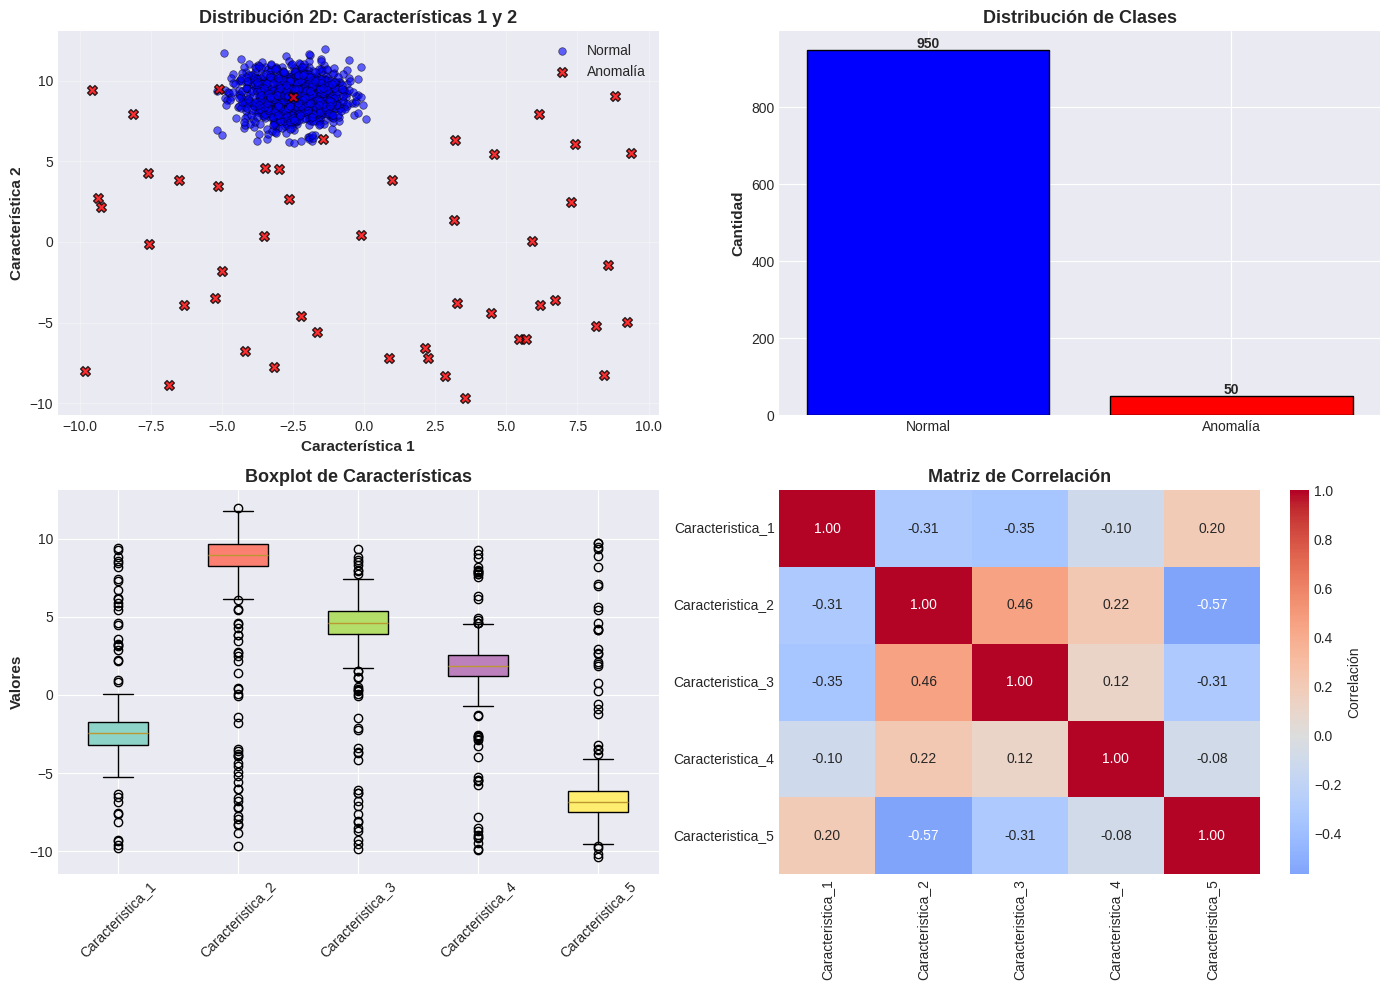

✅ Visualizaciones generadas


In [4]:
print("🎨 Generando visualizaciones exploratorias...")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribución de las primeras 2 características
ax1 = axes[0, 0]
normales = df[df['Es_Anomalia'] == 0]
anomalias_vis = df[df['Es_Anomalia'] == 1]

ax1.scatter(normales['Caracteristica_1'], normales['Caracteristica_2'],
           c='blue', alpha=0.6, s=30, label='Normal', edgecolors='k', linewidth=0.5)
ax1.scatter(anomalias_vis['Caracteristica_1'], anomalias_vis['Caracteristica_2'],
           c='red', alpha=0.8, s=50, label='Anomalía', edgecolors='k', linewidth=1, marker='X')

ax1.set_xlabel('Característica 1', fontsize=11, fontweight='bold')
ax1.set_ylabel('Característica 2', fontsize=11, fontweight='bold')
ax1.set_title('Distribución 2D: Características 1 y 2', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Distribución de anomalías
ax2 = axes[0, 1]
counts = df['Es_Anomalia'].value_counts()
colors = ['blue', 'red']
ax2.bar(['Normal', 'Anomalía'], counts, color=colors, edgecolor='black')
ax2.set_ylabel('Cantidad', fontsize=11, fontweight='bold')
ax2.set_title('Distribución de Clases', fontsize=13, fontweight='bold')

# Añadir valores encima de las barras
for i, v in enumerate(counts):
    ax2.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico 3: Boxplot de características para detectar outliers visualmente
ax3 = axes[1, 0]
df_boxplot = df.drop(columns=['Es_Anomalia', 'Tipo'])
bp = ax3.boxplot(df_boxplot.values, labels=columnas, patch_artist=True)
ax3.set_ylabel('Valores', fontsize=11, fontweight='bold')
ax3.set_title('Boxplot de Características', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# Colorear boxes
for patch, color in zip(bp['boxes'], plt.cm.Set3(np.linspace(0, 1, len(columnas)))):
    patch.set_facecolor(color)

# Gráfico 4: Matriz de correlación
ax4 = axes[1, 1]
corr_matrix = df_boxplot.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax4, cbar_kws={'label': 'Correlación'})
ax4.set_title('Matriz de Correlación', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")

# 4. Preprocesamiento de Datos


In [5]:
print("🔧 Preprocesando datos...")
print("=" * 60)

# Separar características y etiquetas
X_data = df.drop(columns=['Es_Anomalia', 'Tipo']).values
y_true = df['Es_Anomalia'].values

# Estandarizar los datos (importante para muchos algoritmos)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

print(f"✅ Datos preprocesados correctamente")
print(f"   - Dimensiones de X: {X_scaled.shape}")
print(f"   - Media después de escalar: {X_scaled.mean():.6f}")
print(f"   - Desviación estándar después de escalar: {X_scaled.std():.6f}")

🔧 Preprocesando datos...
✅ Datos preprocesados correctamente
   - Dimensiones de X: (1000, 5)
   - Media después de escalar: 0.000000
   - Desviación estándar después de escalar: 1.000000


# 5. Implementación de Isolation Forest


In [6]:
print("🌲 Implementando Isolation Forest...")
print("=" * 60)

# Explicación del algoritmo
print("""
📚 ALGORITMO ISOLATION FOREST:
1. Construye múltiples árboles de aislamiento (iTrees)
2. En cada árbol:
   - Selecciona aleatoriamente una característica
   - Selecciona aleatoriamente un valor de división entre min y max
   - Divide los datos basándose en este valor
3. Las anomalías tienen caminos más cortos en los árboles
4. Calcula el score de anomalía basado en la longitud promedio del camino
""")

# Parámetros del modelo (explicados)
contamination = 0.05  # Proporción esperada de anomalías
n_estimators = 100    # Número de árboles
max_samples = 256     # Muestras por árbol

print(f"⚙️  Parámetros del modelo:")
print(f"   - contamination (contaminación esperada): {contamination}")
print(f"   - n_estimators (número de árboles): {n_estimators}")
print(f"   - max_samples (muestras por árbol): {max_samples}")

# Crear y entrenar el modelo
iso_forest = IsolationForest(
    n_estimators=n_estimators,
    max_samples=max_samples,
    contamination=contamination,
    random_state=42,
    verbose=0
)

# Entrenar el modelo
iso_forest.fit(X_scaled)

print("✅ Modelo Isolation Forest entrenado exitosamente")

# Predecir anomalías
# Nota: Isolation Forest devuelve -1 para anomalías, 1 para normales
y_pred_iso = iso_forest.predict(X_scaled)

# Convertir a formato binario (0=normal, 1=anomalía)
y_pred = np.where(y_pred_iso == -1, 1, 0)

# Obtener scores de anomalía (valores más altos = más anómalo)
anomaly_scores = -iso_forest.decision_function(X_scaled)  # Negativo para mayor score = más anómalo

print(f"\n📊 Resultados de predicción:")
print(f"   - Anomalías detectadas: {sum(y_pred)} ({sum(y_pred)/len(y_pred)*100:.1f}%)")
print(f"   - Anomalías reales: {sum(y_true)}")

🌲 Implementando Isolation Forest...

📚 ALGORITMO ISOLATION FOREST:
1. Construye múltiples árboles de aislamiento (iTrees)
2. En cada árbol:
   - Selecciona aleatoriamente una característica
   - Selecciona aleatoriamente un valor de división entre min y max
   - Divide los datos basándose en este valor
3. Las anomalías tienen caminos más cortos en los árboles
4. Calcula el score de anomalía basado en la longitud promedio del camino

⚙️  Parámetros del modelo:
   - contamination (contaminación esperada): 0.05
   - n_estimators (número de árboles): 100
   - max_samples (muestras por árbol): 256
✅ Modelo Isolation Forest entrenado exitosamente

📊 Resultados de predicción:
   - Anomalías detectadas: 50 (5.0%)
   - Anomalías reales: 50


# 6. Evaluación del Modelo


In [7]:
print("📈 Evaluando modelo...")
print("=" * 60)

# Métricas de evaluación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("📊 Métricas de evaluación:")
print(f"   - Accuracy (Exactitud): {accuracy:.4f}")
print(f"   - Precision (Precisión): {precision:.4f}")
print(f"   - Recall (Sensibilidad): {recall:.4f}")
print(f"   - F1-Score: {f1:.4f}")

# Matriz de confusión
print("\n🎯 Matriz de confusión:")
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm,
                     index=['Real Normal', 'Real Anomalía'],
                     columns=['Pred Normal', 'Pred Anomalía'])
print(cm_df)

# Reporte de clasificación detallado
print("\n📋 Reporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalía']))

📈 Evaluando modelo...
📊 Métricas de evaluación:
   - Accuracy (Exactitud): 0.9980
   - Precision (Precisión): 0.9800
   - Recall (Sensibilidad): 0.9800
   - F1-Score: 0.9800

🎯 Matriz de confusión:
               Pred Normal  Pred Anomalía
Real Normal            949              1
Real Anomalía            1             49

📋 Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       950
    Anomalía       0.98      0.98      0.98        50

    accuracy                           1.00      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000



# 7. Visualización de Resultados


🎨 Generando visualizaciones de resultados...


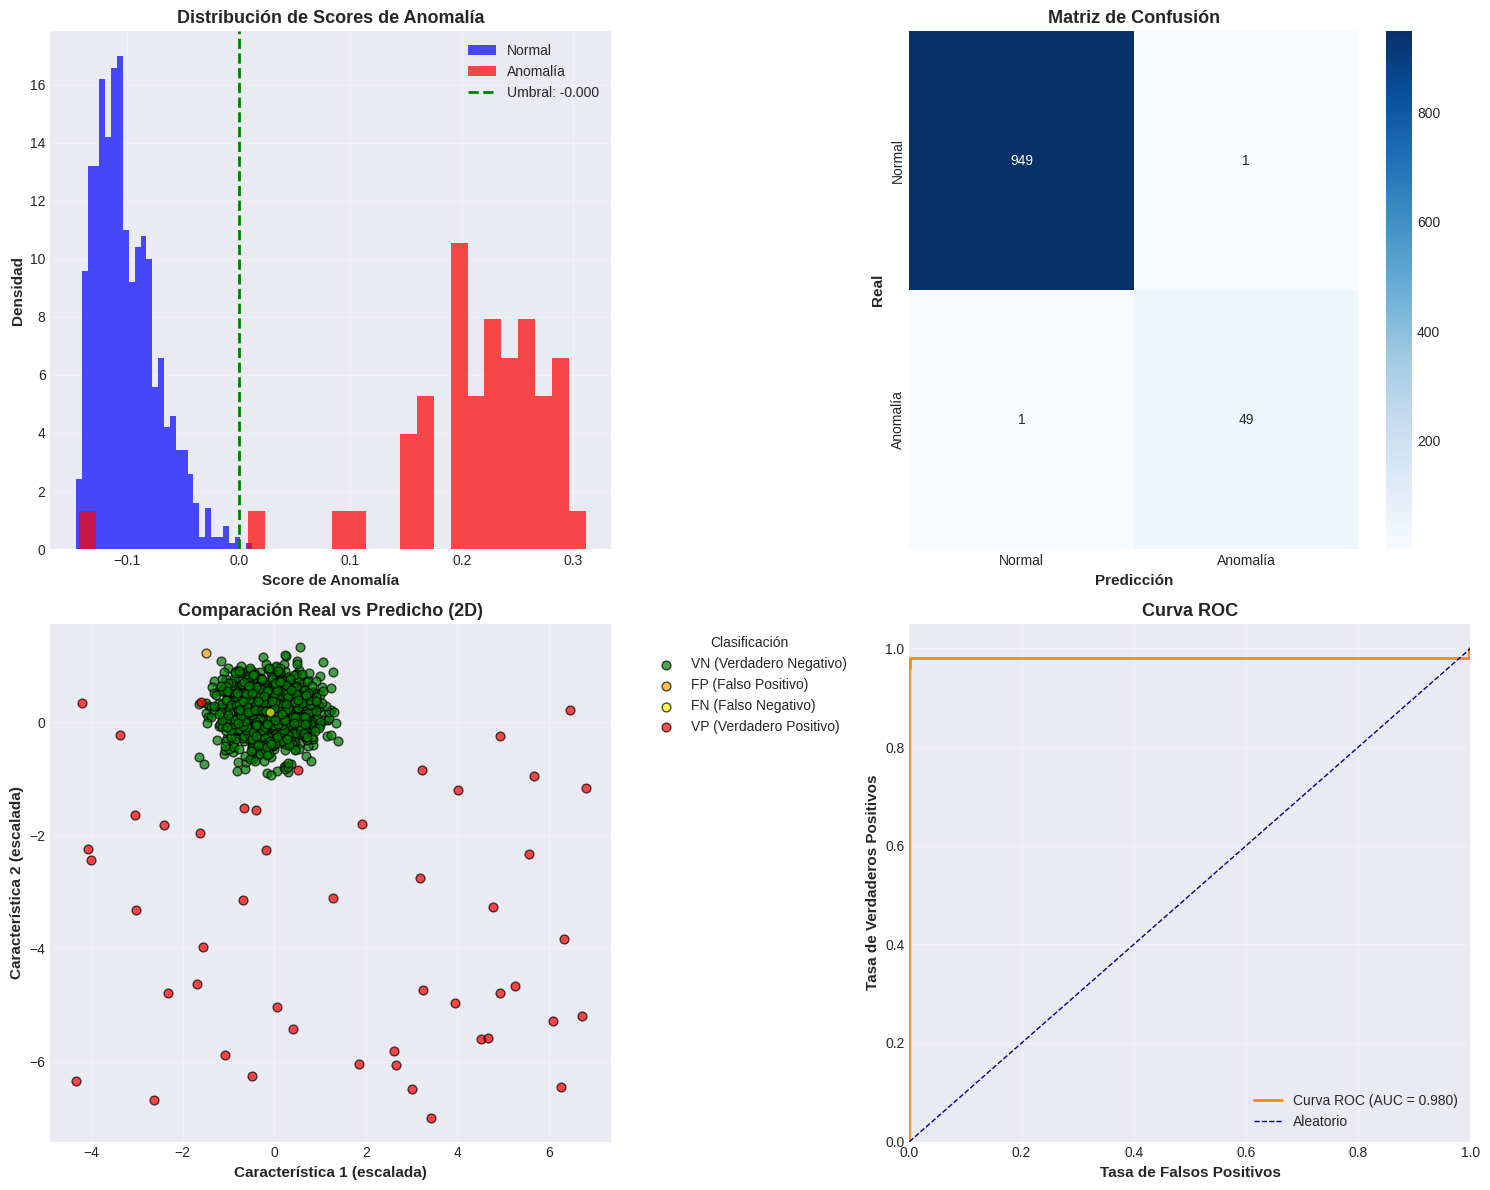

✅ Visualizaciones generadas


In [9]:
print("🎨 Generando visualizaciones de resultados...")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Distribución de scores de anomalía
ax1 = axes[0, 0]
bins = 30

# Verificar que tenemos datos para ambas clases
if len(anomaly_scores[y_true == 0]) > 0 and len(anomaly_scores[y_true == 1]) > 0:
    ax1.hist(anomaly_scores[y_true == 0], bins=bins, alpha=0.7,
             color='blue', label='Normal', density=True)
    ax1.hist(anomaly_scores[y_true == 1], bins=bins, alpha=0.7,
             color='red', label='Anomalía', density=True)
else:
    # Si no hay datos de alguna clase, mostrar todos juntos
    ax1.hist(anomaly_scores, bins=bins, alpha=0.7,
             color='purple', label='Todos los datos', density=True)

ax1.set_xlabel('Score de Anomalía', fontsize=11, fontweight='bold')
ax1.set_ylabel('Densidad', fontsize=11, fontweight='bold')
ax1.set_title('Distribución de Scores de Anomalía', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Línea de decisión (umbral) - solo si hay datos
if len(anomaly_scores) > 0:
    umbral = np.percentile(anomaly_scores, 100 * (1 - contamination))
    ax1.axvline(x=umbral, color='green', linestyle='--', linewidth=2,
                label=f'Umbral: {umbral:.3f}')
    ax1.legend()

# Gráfico 2: Matriz de confusión visual
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'])
ax2.set_xlabel('Predicción', fontsize=11, fontweight='bold')
ax2.set_ylabel('Real', fontsize=11, fontweight='bold')
ax2.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')

# Gráfico 3: Comparación real vs predicho (2D) - VERSIÓN CORREGIDA
ax3 = axes[1, 0]

# Crear arrays de booleanos para cada condición
vn_mask = (y_true == 0) & (y_pred == 0)  # Verdaderos negativos
fp_mask = (y_true == 0) & (y_pred == 1)  # Falsos positivos
fn_mask = (y_true == 1) & (y_pred == 0)  # Falsos negativos
vp_mask = (y_true == 1) & (y_pred == 1)  # Verdaderos positivos

# Verificar que tenemos datos para graficar
if X_scaled.shape[1] >= 2:
    # Graficar cada categoría por separado
    if np.any(vn_mask):
        ax3.scatter(X_scaled[vn_mask, 0], X_scaled[vn_mask, 1],
                   c='green', label='VN (Verdadero Negativo)',
                   alpha=0.7, s=40, edgecolors='k')

    if np.any(fp_mask):
        ax3.scatter(X_scaled[fp_mask, 0], X_scaled[fp_mask, 1],
                   c='orange', label='FP (Falso Positivo)',
                   alpha=0.7, s=40, edgecolors='k')

    if np.any(fn_mask):
        ax3.scatter(X_scaled[fn_mask, 0], X_scaled[fn_mask, 1],
                   c='yellow', label='FN (Falso Negativo)',
                   alpha=0.7, s=40, edgecolors='k')

    if np.any(vp_mask):
        ax3.scatter(X_scaled[vp_mask, 0], X_scaled[vp_mask, 1],
                   c='red', label='VP (Verdadero Positivo)',
                   alpha=0.7, s=40, edgecolors='k')

    ax3.set_xlabel('Característica 1 (escalada)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Característica 2 (escalada)', fontsize=11, fontweight='bold')
    ax3.set_title('Comparación Real vs Predicho (2D)', fontsize=13, fontweight='bold')
    ax3.legend(title='Clasificación', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'No hay suficientes características\npara visualización 2D',
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Comparación Real vs Predicho', fontsize=13, fontweight='bold')

# Gráfico 4: Curva ROC (si es aplicable)
ax4 = axes[1, 1]

# Verificar que tenemos al menos 2 clases
if len(np.unique(y_true)) >= 2:
    fpr, tpr, thresholds = roc_curve(y_true, anomaly_scores)
    roc_auc = auc(fpr, tpr)

    ax4.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.3f})')
    ax4.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Aleatorio')
    ax4.set_xlim([0.0, 1.0])
    ax4.set_ylim([0.0, 1.05])
    ax4.set_xlabel('Tasa de Falsos Positivos', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11, fontweight='bold')
    ax4.set_title('Curva ROC', fontsize=13, fontweight='bold')
    ax4.legend(loc="lower right")
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No hay suficientes clases\npara calcular curva ROC',
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('Curva ROC (No disponible)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")

# 8. Interpretación de Resultados y Ejemplos


In [11]:
"""
8. INTERPRETACIÓN DE RESULTADOS Y EJEMPLOS
------------------------------------------
Analizamos casos específicos y entendemos cómo funciona el modelo.
"""

print("🔍 Interpretando resultados...")
print("=" * 60)

# Crear DataFrame con resultados - VERSIÓN CORREGIDA
resultados_df = pd.DataFrame({
    'Caracteristica_1': X_data[:, 0] if X_data.shape[1] > 0 else np.zeros(len(y_true)),
    'Caracteristica_2': X_data[:, 1] if X_data.shape[1] > 1 else np.zeros(len(y_true)),
    'Score_Anomalia': anomaly_scores,
    'Real': y_true,
    'Prediccion': y_pred
})

# Añadir clasificación simple
resultados_df['Clasificacion'] = np.where(
    resultados_df['Real'] == resultados_df['Prediccion'],
    'Correcto',
    'Incorrecto'
)

# Añadir etiquetas de clasificación detallada - USANDO np.where() EN LUGAR DE np.select()
resultados_df['Clasificacion_Detallada'] = 'Desconocido'

# Aplicar cada condición por separado
# Verdaderos Negativos
mask_vn = (resultados_df['Real'] == 0) & (resultados_df['Prediccion'] == 0)
resultados_df.loc[mask_vn, 'Clasificacion_Detallada'] = 'Verdadero Negativo'

# Falsos Positivos
mask_fp = (resultados_df['Real'] == 0) & (resultados_df['Prediccion'] == 1)
resultados_df.loc[mask_fp, 'Clasificacion_Detallada'] = 'Falso Positivo'

# Falsos Negativos
mask_fn = (resultados_df['Real'] == 1) & (resultados_df['Prediccion'] == 0)
resultados_df.loc[mask_fn, 'Clasificacion_Detallada'] = 'Falso Negativo'

# Verdaderos Positivos
mask_vp = (resultados_df['Real'] == 1) & (resultados_df['Prediccion'] == 1)
resultados_df.loc[mask_vp, 'Clasificacion_Detallada'] = 'Verdadero Positivo'

print(f"📊 Resumen de clasificaciones:")
print(f"   - Total de muestras: {len(resultados_df)}")
for categoria in ['Verdadero Negativo', 'Falso Positivo', 'Falso Negativo', 'Verdadero Positivo']:
    count = len(resultados_df[resultados_df['Clasificacion_Detallada'] == categoria])
    if count > 0:
        print(f"   - {categoria}: {count} ({count/len(resultados_df)*100:.1f}%)")

# Mostrar los 10 puntos con mayor score de anomalía
print("\n🔝 Top 10 puntos más anómalos:")
if len(resultados_df) > 0:
    top_anomalos = resultados_df.nlargest(min(10, len(resultados_df)), 'Score_Anomalia')

    # Seleccionar columnas disponibles
    columnas_disponibles = []
    for col in ['Caracteristica_1', 'Caracteristica_2', 'Score_Anomalia', 'Real', 'Prediccion', 'Clasificacion_Detallada']:
        if col in top_anomalos.columns:
            columnas_disponibles.append(col)

    print(top_anomalos[columnas_disponibles].to_string(index=False))
else:
    print("   No hay datos para mostrar")

# Mostrar ejemplos de cada categoría
print("\n📝 Ejemplos de cada categoría de clasificación:")
categorias = ['Verdadero Positivo', 'Verdadero Negativo', 'Falso Positivo', 'Falso Negativo']

for categoria in categorias:
    ejemplos = resultados_df[resultados_df['Clasificacion_Detallada'] == categoria]
    if len(ejemplos) > 0:
        print(f"\n  {categoria}:")
        ejemplo = ejemplos.iloc[0]

        # Mostrar características disponibles
        if 'Caracteristica_1' in ejemplo:
            print(f"    - Característica 1: {ejemplo['Caracteristica_1']:.3f}")
        if 'Caracteristica_2' in ejemplo:
            print(f"    - Característica 2: {ejemplo['Caracteristica_2']:.3f}")

        print(f"    - Score de anomalía: {ejemplo['Score_Anomalia']:.3f}")
        print(f"    - Real: {'Anomalía' if ejemplo['Real'] == 1 else 'Normal'}")
        print(f"    - Predicción: {'Anomalía' if ejemplo['Prediccion'] == 1 else 'Normal'}")
        print(f"    - Número de muestras en esta categoría: {len(ejemplos)}")

# Análisis de umbral
print(f"\n📊 Análisis del umbral de decisión:")
if len(anomaly_scores) > 0:
    print(f"   - Umbral actual (percentil {100 * (1 - contamination)}%): {umbral:.3f}")
    print(f"   - Scores mínimo: {anomaly_scores.min():.3f}")
    print(f"   - Scores máximo: {anomaly_scores.max():.3f}")
    print(f"   - Scores promedio: {anomaly_scores.mean():.3f}")
    print(f"   - Mediana de scores: {np.median(anomaly_scores):.3f}")

    # Distribución de scores por percentiles
    print(f"\n   📈 Distribución por percentiles:")
    for p in [5, 25, 50, 75, 95]:
        valor = np.percentile(anomaly_scores, p)
        print(f"     - Percentil {p}%: {valor:.3f}")
else:
    print("   No hay scores de anomalía disponibles")

# Sugerir ajuste de umbral si es necesario
print(f"\n🎯 RECOMENDACIONES DE AJUSTE:")

# Calcular métricas si están disponibles
try:
    from sklearn.metrics import precision_score, recall_score
    precision = precision_score(y_true, y_pred) if len(np.unique(y_true)) >= 2 else 0
    recall = recall_score(y_true, y_pred) if len(np.unique(y_true)) >= 2 else 0

    if recall < 0.6:
        print(f"   ⚠️  Recall ({recall:.3f}) es bajo:")
        print(f"      - Solo detecta el {recall*100:.1f}% de las anomalías reales")
        print(f"      - Recomendación: Disminuir 'contamination' (actual: {contamination})")
        print(f"      - Prueba con: contamination={max(0.01, contamination * 0.7):.3f}")

    elif precision < 0.6:
        print(f"   ⚠️  Precisión ({precision:.3f}) es baja:")
        print(f"      - Solo el {precision*100:.1f}% de las detecciones son anomalías reales")
        print(f"      - Recomendación: Aumentar 'contamination' (actual: {contamination})")
        print(f"      - Prueba con: contamination={min(0.5, contamination * 1.5):.3f}")

    else:
        print(f"   ✅ Balance adecuado:")
        print(f"      - Precisión: {precision:.3f} ({precision*100:.1f}% correctas)")
        print(f"      - Recall: {recall:.3f} ({recall*100:.1f}% detectadas)")
        print(f"      - F1-Score: {2 * precision * recall / (precision + recall):.3f}")

        # Sugerir ajustes finos
        if recall > precision * 1.5:
            print(f"      - 💡 El recall es mucho mayor que la precisión")
            print(f"        Podrías aumentar 'contamination' para ser más estricto")
        elif precision > recall * 1.5:
            print(f"      - 💡 La precisión es mucho mayor que el recall")
            print(f"        Podrías disminuir 'contamination' para detectar más anomalías")

except Exception as e:
    print(f"   No se pudieron calcular métricas detalladas: {e}")

# Análisis adicional de resultados
print(f"\n📋 RESUMEN ESTADÍSTICO POR CLASIFICACIÓN:")
if len(resultados_df) > 0:
    for categoria in ['Correcto', 'Incorrecto']:
        mask = resultados_df['Clasificacion'] == categoria
        if mask.any():
            subset = resultados_df[mask]
            print(f"\n   {categoria}: {len(subset)} muestras ({len(subset)/len(resultados_df)*100:.1f}%)")
            if 'Score_Anomalia' in subset.columns:
                print(f"      - Score promedio: {subset['Score_Anomalia'].mean():.3f}")
                print(f"      - Score mínimo: {subset['Score_Anomalia'].min():.3f}")
                print(f"      - Score máximo: {subset['Score_Anomalia'].max():.3f}")

print(f"\n✅ Interpretación completada")

🔍 Interpretando resultados...
📊 Resumen de clasificaciones:
   - Total de muestras: 1000
   - Verdadero Negativo: 949 (94.9%)
   - Falso Positivo: 1 (0.1%)
   - Falso Negativo: 1 (0.1%)
   - Verdadero Positivo: 49 (4.9%)

🔝 Top 10 puntos más anómalos:
 Caracteristica_1  Caracteristica_2  Score_Anomalia  Real  Prediccion Clasificacion_Detallada
         2.150897         -6.589518        0.311251     1           1      Verdadero Positivo
         8.566371         -1.436317        0.292192     1           1      Verdadero Positivo
         5.444895         -6.025686        0.290658     1           1      Verdadero Positivo
         8.437485         -8.230150        0.285983     1           1      Verdadero Positivo
         0.853922         -7.181516        0.284948     1           1      Verdadero Positivo
         8.165318         -5.208762        0.284841     1           1      Verdadero Positivo
         2.840633         -8.317201        0.280307     1           1      Verdadero Posit

# 9. Exportación de Resultados


In [12]:
print("💾 Exportando resultados...")
print("=" * 60)

# Guardar dataset original
dataset_filename = 'dataset_anomalias.csv'
df.to_csv(dataset_filename, index=False)
print(f"✅ Dataset guardado como: {dataset_filename}")

# Guardar resultados completos
resultados_filename = 'resultados_deteccion_anomalias.csv'
resultados_df.to_csv(resultados_filename, index=False)
print(f"✅ Resultados guardados como: {resultados_filename}")

# Guardar métricas de evaluación
metricas = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1_Score': f1,
    'AUC_ROC': roc_auc,
    'Contamination': contamination,
    'N_Estimators': n_estimators
}

metricas_df = pd.DataFrame([metricas])
metricas_filename = 'metricas_modelo.csv'
metricas_df.to_csv(metricas_filename, index=False)
print(f"✅ Métricas guardadas como: {metricas_filename}")

# Información de archivos generados
print("\n📁 ARCHIVOS GENERADOS:")
print(f"   1. {dataset_filename} - Dataset original con anomalías")
print(f"   2. {resultados_filename} - Resultados detallados de clasificación")
print(f"   3. {metricas_filename} - Métricas de evaluación del modelo")

# Mostrar resumen final
print("\n" + "=" * 60)
print("RESUMEN FINAL - DETECCIÓN DE ANOMALÍAS CON ISOLATION FOREST")
print("=" * 60)
print(f"📊 DATASET:")
print(f"   - Muestras: {len(df)}")
print(f"   - Características: {n_caracteristicas}")
print(f"   - Anomalías reales: {sum(y_true)} ({sum(y_true)/len(y_true)*100:.1f}%)")

print(f"\n🎯 RESULTADOS:")
print(f"   - Anomalías detectadas: {sum(y_pred)} ({sum(y_pred)/len(y_pred)*100:.1f}%)")
print(f"   - Accuracy: {accuracy:.3f}")
print(f"   - F1-Score: {f1:.3f}")
print(f"   - AUC-ROC: {roc_auc:.3f}")

print(f"\n✅ PROCESO COMPLETADO EXITOSAMENTE")
print("=" * 60)

💾 Exportando resultados...
✅ Dataset guardado como: dataset_anomalias.csv
✅ Resultados guardados como: resultados_deteccion_anomalias.csv
✅ Métricas guardadas como: metricas_modelo.csv

📁 ARCHIVOS GENERADOS:
   1. dataset_anomalias.csv - Dataset original con anomalías
   2. resultados_deteccion_anomalias.csv - Resultados detallados de clasificación
   3. metricas_modelo.csv - Métricas de evaluación del modelo

RESUMEN FINAL - DETECCIÓN DE ANOMALÍAS CON ISOLATION FOREST
📊 DATASET:
   - Muestras: 1000
   - Características: 5
   - Anomalías reales: 50 (5.0%)

🎯 RESULTADOS:
   - Anomalías detectadas: 50 (5.0%)
   - Accuracy: 0.998
   - F1-Score: 0.980
   - AUC-ROC: 0.980

✅ PROCESO COMPLETADO EXITOSAMENTE
